In [34]:
import sys

package_path = ".."
if package_path not in sys.path:
    sys.path.append(package_path)

In [35]:
%reload_ext autoreload
%autoreload 2

In [36]:
import os
import sys
from pathlib import Path

package_path: str = ".."
if package_path not in sys.path:
    sys.path.append(package_path)
    print(f"Added {Path(package_path).resolve()} to sys.path")

working_dir: Path = Path.cwd()
while working_dir.name != "QoraFlow":
    working_dir = working_dir.parent
os.chdir(working_dir)
print(f"Current working directory set to {working_dir.resolve()}")

Current working directory set to /home/hxpp-admin/Desktop/sogang260903/QoraFlow


In [52]:
import matplotlib.pyplot as plt
import numpy as np

from QoraFlow.config import ConfigManager, ExpConfig
from QoraFlow.logger import Logger, setup_logger

ConfigManager.initialize("config.yaml")
config: ExpConfig = ConfigManager.load_config()
logger: Logger = setup_logger()

In [53]:
# Dimension Check
import zarr

run_n = 56

file = config.path.load_dir / "archive" / f"run{run_n:05}" / "scan00001" / "raw.zarr"
root = zarr.open(file, mode='r')

det = root['det-eh1-jungfrau2']
for key in root.keys():
    print(key, root[key].shape)

det-eh1-jungfrau2 (61, 300, 512, 1024)
qbpm_oh1_qbpm2 (61, 300, 4, 32768)
qbpm_eh1_qbpm1 (61, 300, 4, 32768)
index (61, 300, 2)


In [50]:

line2 = det[:,:,5,5]

In [51]:
len(np.where(np.isnan(line2))[0])

5

/tmp/ipykernel_2272255/1733944403.py:6: RuntimeWarning: invalid value encountered in log
  axis.imshow(np.log(img))


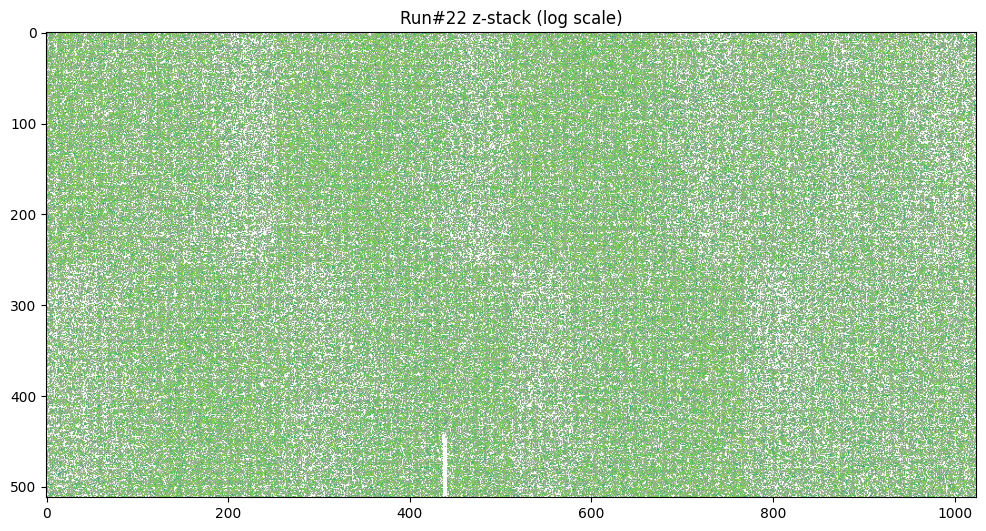

In [ ]:
import matplotlib.pyplot as plt

num_frames = det.shape[0]
mid_num = num_frames // 2
fig, axis = plt.subplots(1, 1, figsize=(12, 9))

axis.set_title(f"Run#{run_n}")
axis.imshow(np.log(det[0:]))

In [19]:
import matplotlib.pyplot as plt
import zarr

run_n = 22

file = config.path.load_dir / f"run{run_n:05}" / "scan00001" / "raw.zarr"
root = zarr.open(file, mode='r')

det2 = root['det-eh1-jungfrau2']
shape = det2.shape
chunks = det2.chunks

print(shape, chunks)

(1, 2100, 512, 1024) (1, 1, 64, 64)


/tmp/ipykernel_2272255/2896389362.py:6: RuntimeWarning: divide by zero encountered in log
  axis.imshow(np.log(safe_img))
/tmp/ipykernel_2272255/2896389362.py:6: RuntimeWarning: invalid value encountered in log
  axis.imshow(np.log(safe_img))


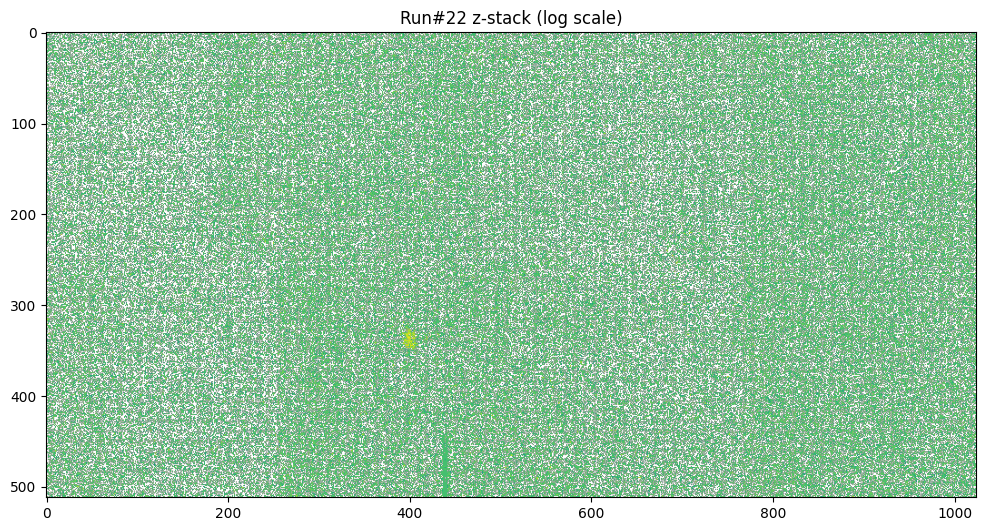

In [ ]:
first_img = det2[0][0]

fig, axis = plt.subplots(1, 1, figsize=(12, 9))

axis.set_title("Run#22 z-stack (log scale)")
axis.imshow(np.log(first_img))

/tmp/ipykernel_2272255/1442866953.py:6: RuntimeWarning: invalid value encountered in log
  ax.imshow(np.log(img), cmap="viridis")


Text(0.5, 1.0, 'ROI Images mean')

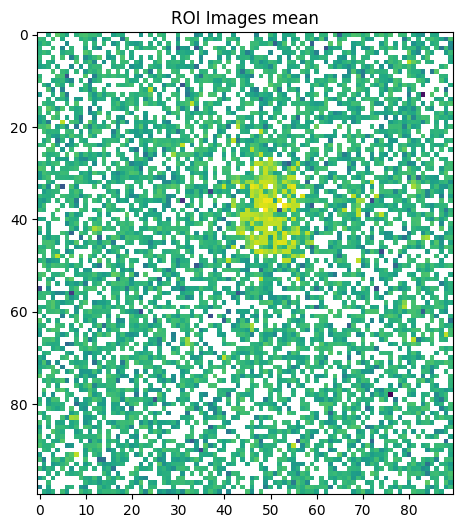

In [ ]:
from roi_rectangle import RoiRectangle

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
rect = RoiRectangle(y1=300, y2=400, x1=350, x2=440)
img = rect.slice(first_img)
ax.imshow(np.log(img), cmap="viridis")
ax.set_title("ROI Images mean")

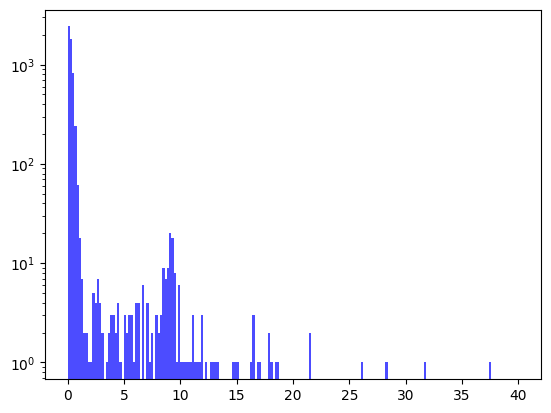

In [21]:
hist, bin_edges = np.histogram(img.ravel(), bins=200, range=(0, 40), density=None)

plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='blue', alpha=0.7, align='edge')
plt.yscale('log')